#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Nicolas Bravo

# Introducción

En este trabajo se va a simular el bloque de cuantización de un ADC, este se utiliza para convertir una señal continua en valores discretos limitados para poder procesarlos en código binario. Se analizará una senoidal contaminada con ruido, este ruido va a estar relacionado a la potencia del ruido de cuantización del ADC dada por la ecuación $P_n = k_n * P_q$ siendo $P_q = \dfrac{q^2}{12}$ el ruido de cuantización, q representando el paso de cuantización $q=\dfrac{2*V_{ref}}{2^B}$ y $V_{ref}$ es el rango dinámico del ADC.

Nuestra variable principal va a ser los Bits del ADC, estos nos van a el nivel de detalle de la señal resultante, a más Bits, mayor será el detalle de la señal de salida.

Primeo creamos la señal con ruido y la cuantizamos:

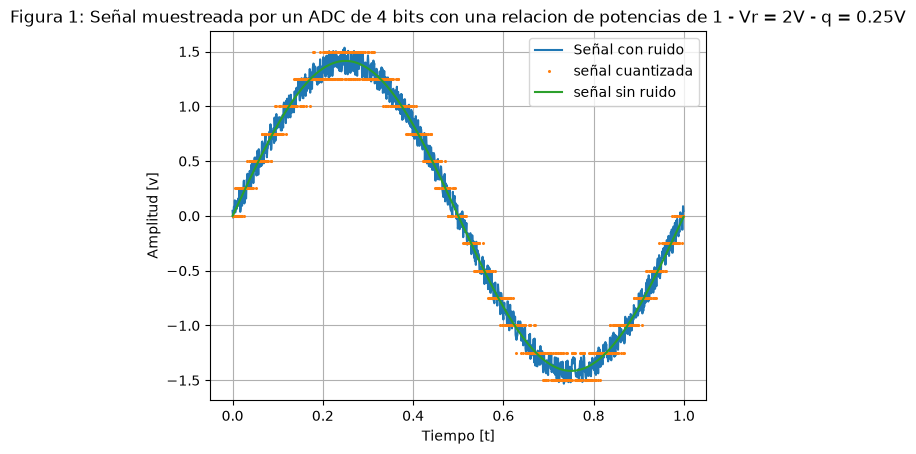

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000           #Cantidad de frecuencia fija
N = 1000            #Cantidad de muestras fijas

#Variables para ir cambiando y que cambie mi funcion
vmax = np.sqrt(2)   #Amplitud maxima de mi señal
pot_in = 1             #Potencia de la señal
dc = 0              #Desplazamiento, me mueve mi señal que queda fija com vmax = 2 para el centro = dc
ff = 1             #Frecuencia variable
ph = 0              #La fase
SNR = 0         #Valor de SNR objetivo con potencia de entrada fija

vfs = 2 #[v] rango de 2v


B = 4
q = 2*vfs/(2**B)    #Paso cuantizacion
k_n = 1             
p_q = q**2/12

#%%
def calculo_limites_unif (var):
    limite = np.sqrt(12*var/4)
    return(limite)

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    xx = (vmax * np.sin(2 * np.pi * ff * np.arange(nn)/fs + ph)) +dc
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    return (tt,xx)

def calculo_c_pot (pot = 1):
    vmax = np.sqrt(pot*2)
    return (vmax)

def ruido (SNR = 0, pot_in = 1):
    pot_r = 10**-((SNR/(-10))-np.log10(pot_in))
    limite = calculo_limites_unif(pot_r)
    xx_rand_unif = np.random.uniform(low = -limite, high = limite, size = 1000)
    return (xx_rand_unif)

def calculo_limites_unif (var):
    limite = np.sqrt(12*var/4)
    return(limite)
#%% Terminan funciones
plt.close("all")
#%% Ruido
tt, xx = mi_funcion_sen( vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs)

p_ruido = k_n * p_q

#%% Secuencia aleatoria normal
limite = calculo_limites_unif(p_ruido)
xx_rand_unif = np.random.uniform(low = -limite, high = limite, size = 1000)     # Distribucion uniforme

xx_ruido = xx + xx_rand_unif
plt.plot(tt, xx_ruido, label='Señal con ruido')

#%% Cuantizacion
xx_q = np.round(xx_ruido / q) * q    #cuantizo la señal con ruido
nq = xx_q - xx_ruido     #ruido
plt.plot(tt, xx_q, 'o', label='señal cuantizada', markersize=1.2)
plt.plot(tt, xx, label='señal sin ruido')
plt.title(f"Figura 1: Señal muestreada por un ADC de {B} bits con una relacion de potencias de {k_n} - Vr = {vfs}V - q = {q}V")
plt.legend(loc='upper right')
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()
nq_norm = nq/q  

Se puede apreciar que la señal cuantizada ocupa valores discretos de amplitud los cuales están separados por la distancia "q".

A continuación, se analiza y compara la densidad de potencia de la señal analógica y la señal cuantizada. 

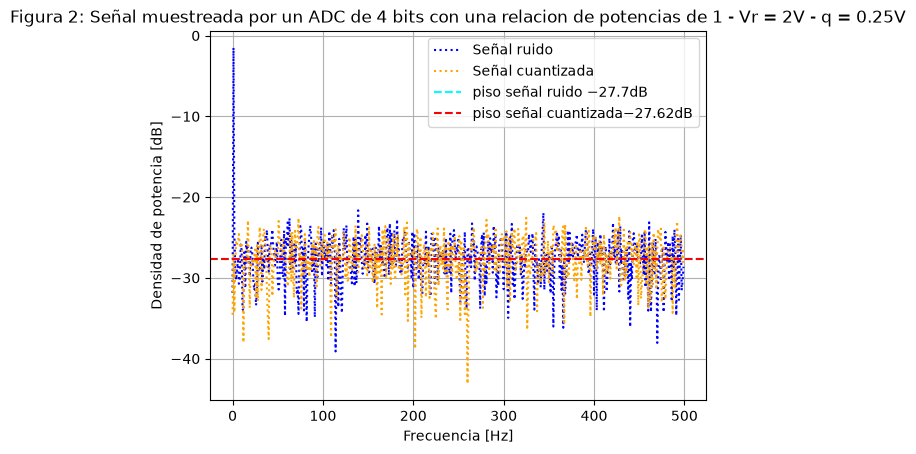

In [2]:
#%% Densidad de potencia
plt.figure()

fftx2 = np.fft.fft(xx_ruido)/N
absfft2 = np.abs(fftx2)
absfft2 = absfft2[:int(N/2)]
fftx_db2 = 10*np.log10(absfft2)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_db2, ':', label ='Señal ruido', color='blue')

fftx3 = np.fft.fft(nq)/N
absfft3 = np.abs(fftx3)
absfft3 = absfft3[:int(N/2)]
fftx_dbq = 10*np.log10(absfft3)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_dbq, ':', label='Señal cuantizada', color='orange')
plt.grid()
#%% Piso de ruido
nr_piso = sum(fftx_db2[20:])/len(fftx_db2[20:])
plt.axhline(nr_piso, label=f'piso señal ruido ${round(nr_piso, 2)}$dB', color='cyan', linestyle = '--')
nq_piso = sum(fftx_dbq[20:])/len(fftx_dbq[20:])
plt.axhline(nq_piso, label=f'piso señal cuantizada${round(nq_piso, 2)}$dB', color='red', linestyle = '--')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.title(f"Figura 2: Señal muestreada por un ADC de {B} bits con una relacion de potencias de {k_n} - Vr = {vfs}V - q = {q}V")
plt.legend(loc='upper right');


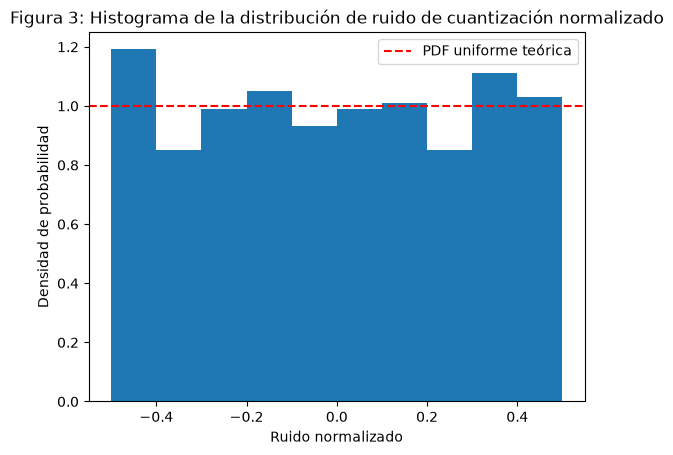

In [3]:
plt.figure()
plt.hist(nq_norm, bins = 10, density = True);
plt.axhline(1, color='red', linestyle='--', label='PDF uniforme teórica')
plt.ylabel("Densidad de probabilidad")
plt.xlabel("Ruido normalizado")
plt.legend()
plt.title("Figura 3: Histograma de la distribución de ruido de cuantización normalizado");

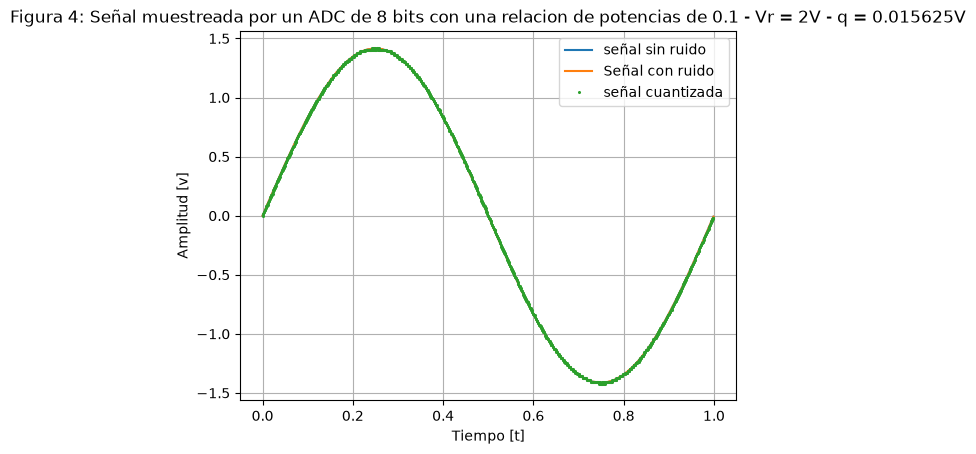

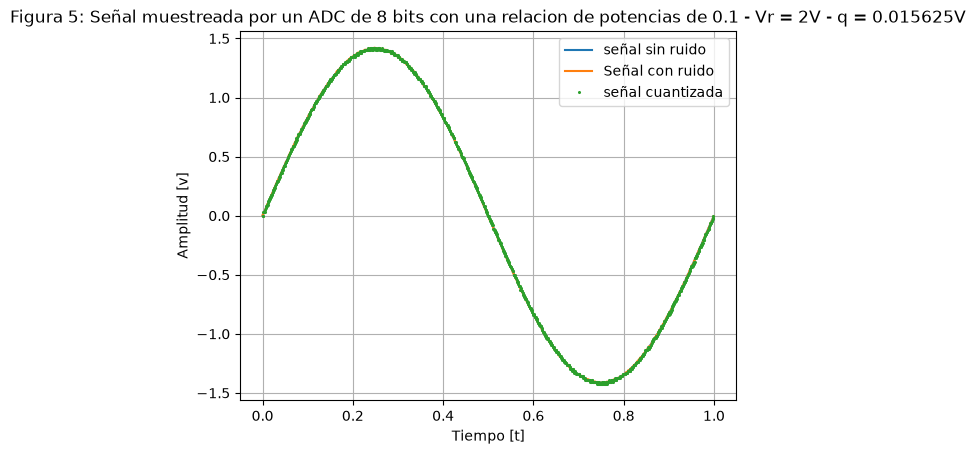

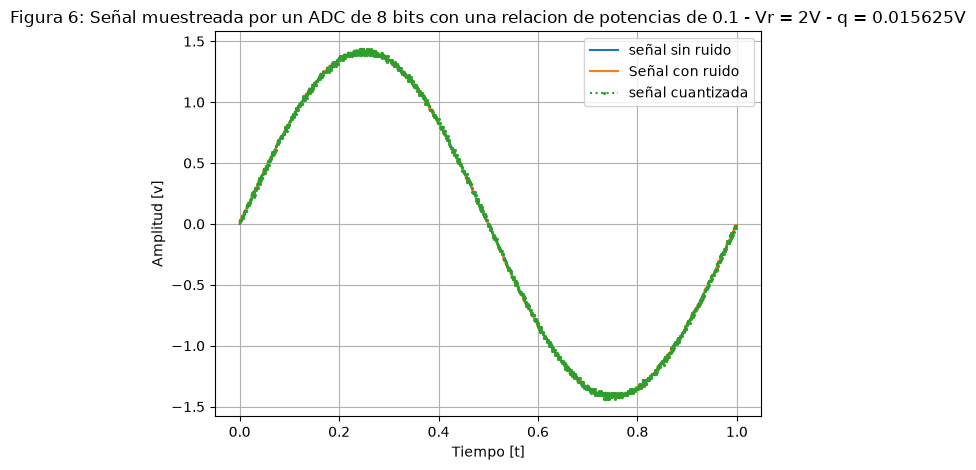

In [4]:
B = 8
q = 2*vfs/(2**B)    #Paso cuantizacion             
p_q = q**2/12
k_n = 1/10       
k_n2 = 1 
k_n3 = 10    
p_ruido = k_n * p_q
p_ruido2 = k_n2 * p_q
p_ruido3 = k_n3 * p_q

#%% Secuencia aleatoria normal
limite = calculo_limites_unif(p_ruido)
xx_rand_unif = np.random.uniform(low = -limite, high = limite, size = 1000)     # Distribucion uniforme

limite2 = calculo_limites_unif(p_ruido2)
xx_rand_unif2 = np.random.uniform(low = -limite2, high = limite2, size = 1000)     # Distribucion uniforme

limite3 = calculo_limites_unif(p_ruido3)
xx_rand_unif3 = np.random.uniform(low = -limite3, high = limite3, size = 1000)     # Distribucion uniforme

xx_ruido = xx + xx_rand_unif
xx_ruido2 = xx + xx_rand_unif2
xx_ruido3 = xx + xx_rand_unif3

#%% Cuantizacion
#k_n
plt.figure()
xx_q = np.round(xx_ruido / q) * q    #cuantizo la señal con ruido
nq = xx_q - xx_ruido     #ruido
plt.plot(tt, xx, label='señal sin ruido')
plt.plot(tt, xx_ruido, label='Señal con ruido')
plt.plot(tt, xx_q, 'o', label='señal cuantizada', markersize=1.2)
plt.title(f"Figura 4: Señal muestreada por un ADC de {B} bits con una relacion de potencias de {k_n} - Vr = {vfs}V - q = {q}V")
plt.legend(loc='upper right')
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()
nq_norm = nq/q  
#k_n2
plt.figure()
xx_q2 = np.round(xx_ruido2 / q) * q    #cuantizo la señal con ruido
nq2 = xx_q2 - xx_ruido2     #ruido
plt.plot(tt, xx, label='señal sin ruido')
plt.plot(tt, xx_ruido2, label='Señal con ruido')
plt.plot(tt, xx_q2, 'o', label='señal cuantizada', markersize=1.2)
plt.title(f"Figura 5: Señal muestreada por un ADC de {B} bits con una relacion de potencias de {k_n} - Vr = {vfs}V - q = {q}V")
plt.legend(loc='upper right')
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()
nq_norm2 = nq2/q  
#k_n3
plt.figure()
xx_q3 = np.round(xx_ruido3 / q) * q    #cuantizo la señal con ruido
nq3 = xx_q3 - xx_ruido3     #ruido
plt.plot(tt, xx, label='señal sin ruido')
plt.plot(tt, xx_ruido3, label='Señal con ruido')
plt.plot(tt, xx_q3, ':o', label='señal cuantizada', markersize=1.2)
plt.title(f"Figura 6: Señal muestreada por un ADC de {B} bits con una relacion de potencias de {k_n} - Vr = {vfs}V - q = {q}V")
plt.legend(loc='upper right')
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()
plt.tight_layout()
nq_norm3 = nq3/q
plt.tight_layout()

Analizando las figuras 4-6 se puede ver que, a mayores valores de k, el ruido de la señal se hace mayor. También se puede observar que a medida que aumentan los bits, la señal digital se aproxima más a la señal original. Esto se debe a que a medida que aumentan los bits, el paso de cuantización "q" se hace más chico, permitiendo una mayor precisión.

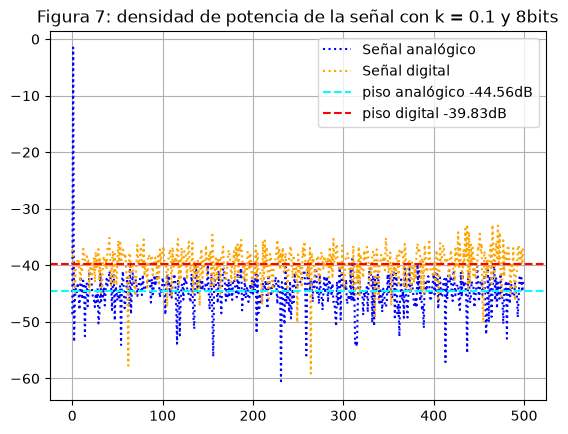

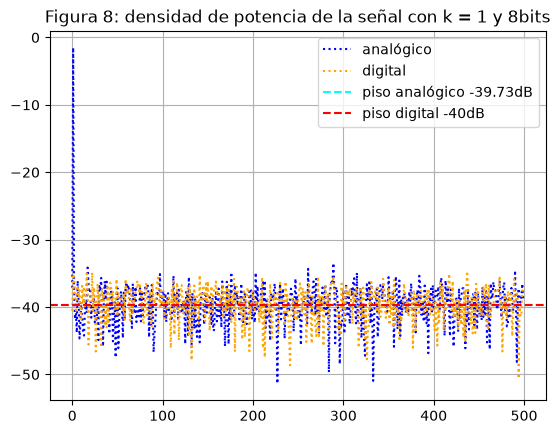

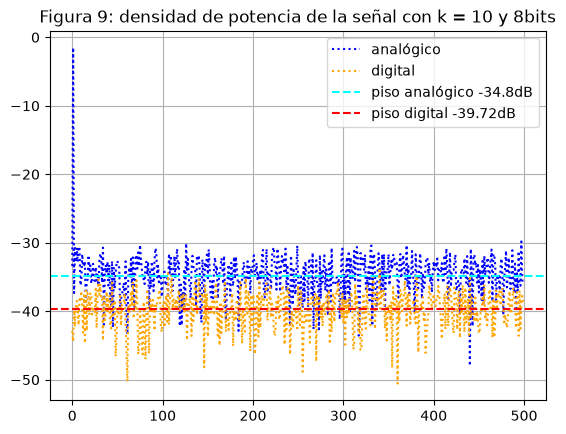

In [5]:
#%% Densidad de potencia
plt.figure()
fftx2 = np.fft.fft(xx_ruido)/N
absfft2 = np.abs(fftx2)
absfft2 = absfft2[:int(N/2)]
fftx_db2 = 10*np.log10(absfft2)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_db2, ':', label ='Señal analógico', color='blue')

fftx3 = np.fft.fft(nq)/N
absfft3 = np.abs(fftx3)
absfft3 = absfft3[:int(N/2)]
fftx_dbq = 10*np.log10(absfft3)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_dbq, ':', label='Señal digital', color='orange')
plt.grid()
#%% Piso de ruido
nr = sum(fftx_db2[20:])/len(fftx_db2[20:])
plt.axhline(nr, label=f'piso analógico {round(nr, 2)}dB', color='cyan', linestyle = '--')
nq_r = sum(fftx_dbq[20:])/len(fftx_dbq[20:])
plt.axhline(nq_r, label=f'piso digital {round(nq_r, 2)}dB', color='red', linestyle = '--')
plt.legend(loc='upper right')
plt.title(f"Figura 7: densidad de potencia de la señal con k = {k_n} y {B}bits")
plt.figure()
#%%2
fftx2 = np.fft.fft(xx_ruido2)/N
absfft2 = np.abs(fftx2)
absfft2 = absfft2[:int(N/2)]
fftx_db2 = 10*np.log10(absfft2)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_db2, ':', label ='analógico', color='blue')

fftx3 = np.fft.fft(nq2)/N
absfft3 = np.abs(fftx3)
absfft3 = absfft3[:int(N/2)]
fftx_dbq = 10*np.log10(absfft3)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_dbq, ':', label='digital', color='orange')
plt.grid()

#%% Piso de ruido 2
nr2 = sum(fftx_db2[20:])/len(fftx_db2[20:])
plt.axhline(nr2, label=f'piso analógico {round(nr2, 2)}dB', color='cyan', linestyle = '--')
nq2_r = sum(fftx_dbq[20:])/len(fftx_dbq[20:])
plt.axhline(nq2_r, label=f'piso digital {round(nq2_r)}dB', color='red', linestyle = '--')
plt.title(f"Figura 8: densidad de potencia de la señal con k = {k_n2} y {B}bits")
plt.legend(loc='upper right');

#%%3
plt.figure()
fftx2 = np.fft.fft(xx_ruido3)/N
absfft2 = np.abs(fftx2)
absfft2 = absfft2[:int(N/2)]
fftx_db2 = 10*np.log10(absfft2)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_db2, ':', label ='analógico', color='blue')

fftx3 = np.fft.fft(nq3)/N
absfft3 = np.abs(fftx3)
absfft3 = absfft3[:int(N/2)]
fftx_dbq = 10*np.log10(absfft3)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
frec = frec[:int(N/2)]
plt.plot(frec, fftx_dbq, ':', label='digital', color='orange')
plt.grid()

#%% Piso de ruido 2
nr3 = sum(fftx_db2[20:])/len(fftx_db2[20:])
plt.axhline(nr3, label=f'piso analógico {round(nr3, 2)}dB', color='cyan', linestyle = '--')
nq3_r = sum(fftx_dbq[20:])/len(fftx_dbq[20:])
plt.axhline(nq3_r, label=f'piso digital {round(nq3_r, 2)}dB', color='red', linestyle = '--')
plt.title(f"Figura 9: densidad de potencia de la señal con k = {k_n3} y {B}bits")
plt.legend(loc='upper right');

Analizando las figuras 7-9 se puede apreciar que varía el piso de señal analógico, ya que el ruido de este está dado por el factor $k_n$, también se puede ver que al aumentar el valor del factor $k_n$ el ruido analógico supera al ruido digital y lo contrario pasa si se disminuye el factor $k_n$. Esto es importante ya que, si el ruido analógico es mayor, el ruido digital va a estar enmascarado por este y no se va a distinguir bien el espectro.

Por último, comparándolo con la figura 2, se puede ver que el ruido digital está relacionado con la cantidad de bits del ADC, a mayor cantidad de bits,  ambos ruidos se hacen menores.